<a href="https://colab.research.google.com/github/amosagekouassi-source/DI-Bootcamp/blob/master/Dalychallenge2_J1_W2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset URL: https://www.kaggle.com/datasets/olgabelitskaya/flower-color-images
License(s): other
flower-color-images.zip: Skipping, found more recently modified local copy (use --force to force download)
replace FlowerColorImages.h5? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Image chargée avec succès : flower_images/flower_images/0064.png


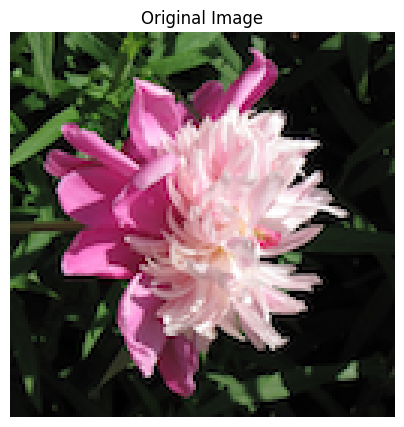

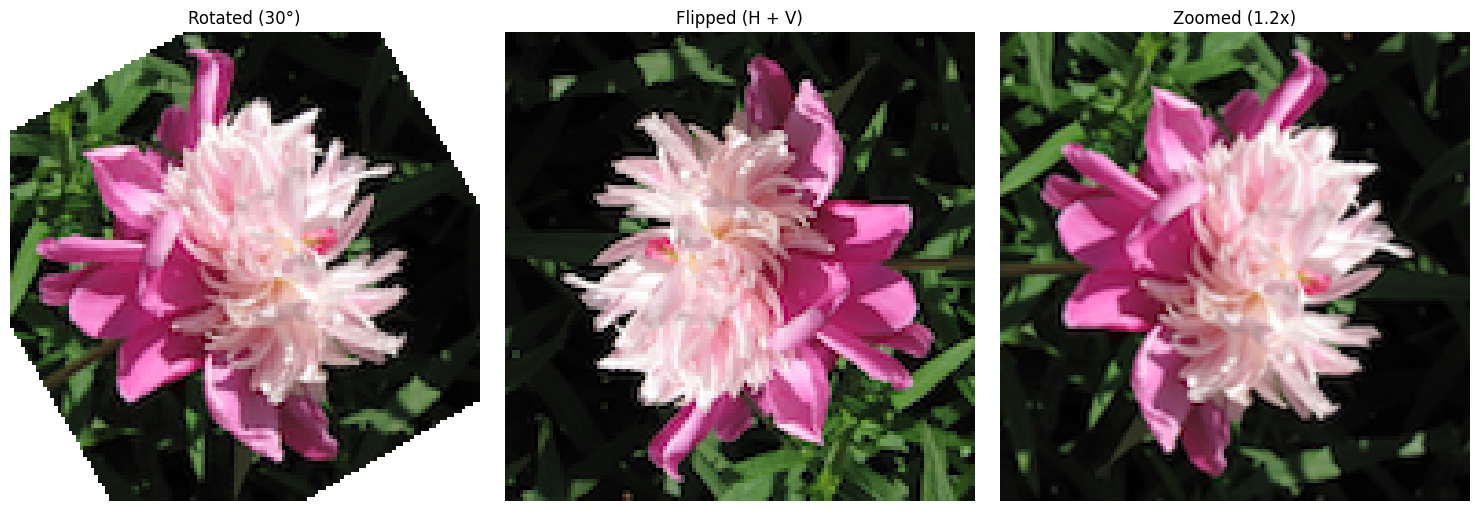

In [4]:
# ==========================================
# 1. TÉLÉCHARGEMENT ET PRÉPARATION DU DATASET
# (Réf: 139873.jpg)
# ==========================================


# Téléchargement du dataset Flower Color Images
!kaggle datasets download -d olgabelitskaya/flower-color-images

# Désarchivage du dataset
!unzip -q flower-color-images.zip

# ==========================================
# 2. INSTALLATION DES BIBLIOTHÈQUES
# (Réf: 139875.jpg)
# ==========================================
!pip install tensorflow keras pillow matplotlib scipy

# ==========================================
# 3. IMPORTATIONS ET CHARGEMENT DE L'IMAGE
# (Réf: 139875.jpg)
# ==========================================
import os
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from scipy.ndimage import rotate

# Définition du chemin de l'image
# Note: On cherche dynamiquement une image dans le dossier extrait si le nom précis varie
image_dir = 'flower_images/flower_images/' if os.path.exists('flower_images') else 'flowers/flowers/'
if os.path.exists(image_dir):
    sample_image_name = os.listdir(image_dir)[0]
    image_path = os.path.join(image_dir, sample_image_name)
else:
    image_path = 'flower_images/0001.png' # Chemin par défaut

# Chargement et affichage de l'image originale
try:
    original_image = Image.open(image_path)
    print(f"Image chargée avec succès : {image_path}")
except FileNotFoundError:
    print("Image introuvable, assurez-vous que le unzip s'est bien déroulé.")

# Affichage initial
plt.figure(figsize=(5, 5))
plt.imshow(original_image)
plt.title("Original Image")
plt.axis('off')
plt.show()

# ==========================================
# 4. FONCTIONS DE TRANSFORMATION D'IMAGE
# (Réf: 139875.jpg & 139877.jpg)
# ==========================================

# --- Rotation de 30 degrés ---
def rotate_image_30_degrees(image):
    # reshape=False permet de garder les dimensions originales de l'image
    return rotate(image, angle=30, reshape=False)

# --- Retournement Horizontal puis Vertical ---
def flip_horizontal_vertical(image):
    # Utilisation de ImageOps de PIL (mirror pour horizontal, flip pour vertical)
    img_flipped_h = ImageOps.mirror(image)
    img_flipped_v = ImageOps.flip(img_flipped_h)
    return img_flipped_v

# --- Zoom (Redimensionnement par 1.2x) ---
def zoom_image_12x(image):
    width, height = image.size
    new_width = int(width * 1.2)
    new_height = int(height * 1.2)
    return image.resize((new_width, new_height))

# ==========================================
# 5. EXÉCUTION ET VISUALISATION DES RÉSULTATS
# ==========================================

# Application des fonctions
rotated_img = rotate_image_30_degrees(original_image)
flipped_img = flip_horizontal_vertical(original_image)
zoomed_img = zoom_image_12x(original_image)

# Affichage des résultats côte à côte
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot Rotation
axes[0].imshow(rotated_img)
axes[0].set_title("Rotated (30°)")
axes[0].axis('off')

# Plot Retournement
axes[1].imshow(flipped_img)
axes[1].set_title("Flipped (H + V)")
axes[1].axis('off')

# Plot Zoom
axes[2].imshow(zoomed_img)
axes[2].set_title("Zoomed (1.2x)")
axes[2].axis('off')

plt.tight_layout()
plt.show()